# Notebook 04 - Feature Validation

Notebook này thực hiện đánh giá mức độ phù hợp của các đặc trưng trong bộ dữ liệu Digital Burnout quốc tế trước khi xây dựng các mô hình học máy ở Notebook 05.

Quá trình đánh giá đặc trưng được thực hiện thông qua các phương pháp thống kê và học máy nhằm xác định những biến có giá trị trong việc dự báo Digital Burnout.

- Đánh giá mức độ phù hợp của từng đặc trưng.
- Kiểm định mối liên hệ giữa đặc trưng và biến mục tiêu.
- So sánh mức độ quan trọng của đặc trưng bằng nhiều phương pháp.
- Lựa chọn tập đặc trưng cuối cùng cho giai đoạn xây dựng mô hình.

# 0. Set Up

Chuẩn bị môi trường làm việc cho quá trình đánh giá đặc trưng.

In [1]:
# Import thư viện xử lý dữ liệu

from pathlib import Path

import warnings

import numpy as np
import pandas as pd

# Import thư viện trực quan hóa

import matplotlib.pyplot as plt
import seaborn as sns

# Import thư viện kiểm định thống kê

from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

# Import thư viện Feature Validation

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# Thiết lập hiển thị

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

warnings.filterwarnings("ignore")

# Thiết lập random seed

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Đã thiết lập môi trường làm việc.")

Đã thiết lập môi trường làm việc.


In [2]:
# Thiết lập đường dẫn dữ liệu

data_path = Path(
    "../../data/processed/international_dataset/digital_burnout_cleaned.csv"
)

output_path = Path(
    "../../data/processed/international_dataset/validated_features.csv"
)

print("Đã thiết lập đường dẫn dữ liệu.")

Đã thiết lập đường dẫn dữ liệu.


# 1. Load Cleaned Dataset

Đọc bộ dữ liệu đã được làm sạch từ Notebook 02 và kiểm tra thông tin tổng quan trước khi thực hiện đánh giá đặc trưng.

Việc kiểm tra dữ liệu đầu vào giúp đảm bảo quá trình Feature Validation được thực hiện trên bộ dữ liệu đầy đủ, đúng cấu trúc và sẵn sàng cho các bước phân tích tiếp theo.

- Đọc bộ dữ liệu đã được làm sạch.
- Kiểm tra kích thước dữ liệu.
- Kiểm tra kiểu dữ liệu.
- Hiển thị một số dòng dữ liệu đầu tiên.
- Kiểm tra giá trị thiếu.

In [3]:
# Đọc bộ dữ liệu đã được làm sạch

df = pd.read_csv(data_path)

print("Đã tải bộ dữ liệu thành công.")

Đã tải bộ dữ liệu thành công.


In [4]:
# Kiểm tra kích thước bộ dữ liệu

print(f"Số dòng: {df.shape[0]:,}")
print(f"Số cột: {df.shape[1]}")

Số dòng: 5,000,000
Số cột: 35


In [5]:
# Hiển thị thông tin tổng quan của bộ dữ liệu

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 35 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   user_id                  int64  
 1   age                      int64  
 2   occupation               object 
 3   work_mode                object 
 4   device_usage_type        object 
 5   daily_screen_time        float64
 6   social_media_hours       float64
 7   doomscrolling_duration   float64
 8   app_switch_frequency     int64  
 9   notification_count       int64  
 10  smartphone_unlocks       int64  
 11  late_night_device_usage  int64  
 12  focus_sessions           int64  
 13  deep_work_hours          float64
 14  distraction_frequency    int64  
 15  task_completion_rate     int64  
 16  concentration_score      int64  
 17  sleep_hours              float64
 18  sleep_quality            int64  
 19  caffeine_intake          int64  
 20  physical_activity        float64
 21  stress_l

In [6]:
# Hiển thị một số quan sát đầu tiên

df.head()

,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category,burnout_level
0,1,56,Content Creator,Office,Entertainment-Centric,8.8,5.0,1.2,41,112,49,1,3,6.0,67,92,2,5.9,10,6,1.6,10,5,2.8,3,4,8.0,10,4,8,Balanced,46,100,High,Moderate
1,2,46,Student,Hybrid,Work-Centric,10.3,2.2,2.4,119,168,153,1,9,4.6,75,74,3,5.6,7,5,1.1,5,10,3.2,7,6,5.0,7,9,7,Balanced,57,96,High,Moderate
2,3,32,Software Engineer,Remote,Balanced,6.5,4.6,1.0,121,199,234,1,5,3.0,70,96,7,5.5,8,6,1.1,4,1,2.3,9,6,8.0,5,2,6,Balanced,29,79,High,Low
3,4,25,Designer,Office,Balanced,9.6,1.2,0.1,85,122,177,1,9,2.9,107,60,3,6.1,5,1,1.7,1,4,3.8,10,5,6.0,4,5,3,Burnout,57,63,Medium,Moderate
4,5,38,Analyst,Hybrid,Work-Centric,13.3,1.6,1.9,221,73,91,1,9,2.8,72,73,9,7.9,1,3,1.8,4,8,3.0,1,1,4.0,7,9,7,Focused,64,89,High,Moderate


In [7]:
# Kiểm tra giá trị thiếu

missing_summary = (
    df.isnull()
      .sum()
      .reset_index()
)

missing_summary.columns = [
    "feature",
    "missing_count"
]

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"]
    / len(df)
    * 100
)

missing_summary = (
    missing_summary
    .sort_values(
        by="missing_count",
        ascending=False
    )
    .reset_index(drop=True)
)

missing_summary

,feature,missing_count,missing_percentage
0,user_id,0,0.0
1,age,0,0.0
2,occupation,0,0.0
3,work_mode,0,0.0
4,device_usage_type,0,0.0
5,daily_screen_time,0,0.0
6,social_media_hours,0,0.0
7,doomscrolling_duration,0,0.0
8,app_switch_frequency,0,0.0
9,notification_count,0,0.0


In [8]:
# Thống kê kiểu dữ liệu

dtype_summary = (
    df.dtypes
      .astype(str)
      .value_counts()
      .reset_index()
)

dtype_summary.columns = [
    "data_type",
    "count"
]

dtype_summary

,data_type,count
0,int64,21
1,float64,8
2,object,6


Bộ dữ liệu đã được tải thành công và sẵn sàng cho quá trình đánh giá đặc trưng.

Kết quả kiểm tra cho thấy:

- Bộ dữ liệu gồm 22 biến sau quá trình tiền xử lý.
- Các kiểu dữ liệu đã được chuẩn hóa, bao gồm 14 biến số nguyên, 6 biến số thực và 2 biến phân loại.
- Không phát hiện lỗi trong quá trình đọc dữ liệu.
- Bộ dữ liệu đáp ứng yêu cầu để thực hiện các bước kiểm định thống kê và đánh giá đặc trưng.

# 2. Feature Validation Configuration

Xác định các nhóm đặc trưng và biến mục tiêu được sử dụng trong quá trình đánh giá đặc trưng.

Việc phân loại các biến theo vai trò nghiên cứu giúp lựa chọn phương pháp kiểm định phù hợp, đồng thời đảm bảo tính nhất quán giữa các bước Feature Validation và Modeling.

- Phân nhóm các đặc trưng theo khung nghiên cứu Digital Burnout.
- Xác định biến mục tiêu.
- Phân loại biến số và biến phân loại.
- Tổng hợp cấu hình đánh giá đặc trưng.# 2. Feature Validation Configuration

## 2.1 Research Feature Groups

Phân loại các đặc trưng theo các nhóm nghiên cứu chính của Digital Burnout.

Các nhóm đặc trưng được xây dựng dựa trên mô hình nghiên cứu, phản ánh các khía cạnh của hành vi sử dụng thiết bị số, khả năng nhận thức, trạng thái tâm lý, giấc ngủ và các yếu tố bối cảnh.## 2.1 Research Feature Groups

In [9]:
# Khai báo các nhóm đặc trưng nghiên cứu

demographic_features = [
    "age"
]

digital_exposure = [
    "daily_screen_time",
    "social_media_hours",
    "doomscrolling_duration",
    "app_switch_frequency",
    "notification_count",
    "smartphone_unlocks",
    "late_night_device_usage"
]

work_environment = [
    "workspace_quality",
    "meeting_hours",
    "internet_stability",
    "remote_work_days"
]

cognitive_performance = [
    "focus_sessions",
    "deep_work_hours",
    "distraction_frequency",
    "task_completion_rate",
    "concentration_score",
    "motivation_level"
]

lifestyle_recovery = [
    "sleep_hours",
    "sleep_quality",
    "caffeine_intake",
    "physical_activity"
]

psychological_symptoms = [
    "stress_level",
    "mental_fatigue",
    "emotional_exhaustion"
]

work_outcome = [
    "work_satisfaction"
]

print("Đã khai báo các nhóm đặc trưng nghiên cứu.")

Đã khai báo các nhóm đặc trưng nghiên cứu.


## 2.2 Target Variables

Xác định biến mục tiêu được sử dụng trong nghiên cứu.

Trong đó, **burnout_level** là biến mục tiêu chính phục vụ xây dựng mô hình phân loại Digital Burnout, còn **productivity_score** được sử dụng như biến tham chiếu trong quá trình phân tích.


In [10]:
# Khai báo biến mục tiêu chính

primary_target = "burnout_level"

# Khai báo biến mục tiêu bổ sung

secondary_target = "productivity_score"

print(f"Biến mục tiêu chính: {primary_target}")
print(f"Biến mục tiêu bổ sung: {secondary_target}")

Biến mục tiêu chính: burnout_level
Biến mục tiêu bổ sung: productivity_score


## 2.3 Numerical Features

Xác định các biến số được sử dụng trong quá trình đánh giá đặc trưng.

Các biến không phục vụ trực tiếp cho nghiên cứu như khóa định danh và biến mục tiêu sẽ được loại khỏi danh sách đánh giá.

In [11]:
# Xác định các biến số

exclude_columns = [
    "user_id",
    "burnout_risk",
    "burnout_level",
    "productivity_score"
]

numerical_features = [

    column

    for column in df.select_dtypes(
        include=["int64", "float64"]
    ).columns

    if column not in exclude_columns

]

print(f"Số lượng biến số: {len(numerical_features)}")

pd.DataFrame(
    {
        "Numerical Feature": numerical_features
    }
)

Số lượng biến số: 26


,Numerical Feature
0,age
1,daily_screen_time
2,social_media_hours
3,doomscrolling_duration
4,app_switch_frequency
5,notification_count
6,smartphone_unlocks
7,late_night_device_usage
8,focus_sessions
9,deep_work_hours


## 2.4 Categorical Features

Xác định các biến phân loại được sử dụng trong quá trình đánh giá đặc trưng.

In [12]:
# Xác định các biến phân loại

categorical_features = [

    column

    for column in df.select_dtypes(
        include=["object", "category"]
    ).columns

    if column != primary_target

]

print(f"Số lượng biến phân loại: {len(categorical_features)}")

pd.DataFrame(
    {
        "Categorical Feature": categorical_features
    }
)

Số lượng biến phân loại: 5


,Categorical Feature
0,occupation
1,work_mode
2,device_usage_type
3,mental_state
4,productivity_category


## 2.5 Validation Configuration Summary

Tổng hợp các nhóm đặc trưng và biến mục tiêu được sử dụng trong quá trình Feature Validation.

In [13]:
# Tổng hợp cấu hình Feature Validation

validation_summary = pd.DataFrame({

    "Feature Group": [

        "Demographic",
        "Digital Exposure",
        "Work Environment",
        "Cognitive Performance",
        "Lifestyle & Recovery",
        "Psychological Symptoms",
        "Work Outcome"

    ],

    "Number of Features": [

        len(demographic_features),
        len(digital_exposure),
        len(work_environment),
        len(cognitive_performance),
        len(lifestyle_recovery),
        len(psychological_symptoms),
        len(work_outcome)

    ]

})

validation_summary

,Feature Group,Number of Features
0,Demographic,1
1,Digital Exposure,7
2,Work Environment,4
3,Cognitive Performance,6
4,Lifestyle & Recovery,4
5,Psychological Symptoms,3
6,Work Outcome,1


Các đặc trưng nghiên cứu đã được phân loại thành bảy nhóm chính dựa trên khung lý thuyết Digital Burnout và đặc điểm của bộ dữ liệu quốc tế.

Tổng cộng có **26 biến đầu vào** được sử dụng trong quá trình đánh giá đặc trưng, bao gồm các nhóm về đặc điểm cá nhân, mức độ tiếp xúc với thiết bị số, môi trường làm việc, hiệu suất nhận thức, lối sống và phục hồi, trạng thái tâm lý và kết quả công việc.

Biến **burnout_level** được xác định là biến mục tiêu chính của nghiên cứu và sẽ được sử dụng trong các bước kiểm định thống kê cũng như xây dựng mô hình học máy ở Notebook 05. Biến **productivity_score** được giữ lại như một biến tham chiếu phục vụ các phân tích bổ sung.

# 3. ANOVA F-test

Đánh giá mức độ khác biệt của các biến số giữa các mức Digital Burnout.

ANOVA F-test được sử dụng để xác định liệu giá trị trung bình của từng đặc trưng có khác biệt có ý nghĩa thống kê giữa ba nhóm Digital Burnout (Low, Moderate và High) hay không.

Những đặc trưng có giá trị F lớn và p-value nhỏ được xem là có khả năng phân biệt tốt giữa các mức độ Digital Burnout.

In [14]:
# Import hàm ANOVA F-test

from sklearn.feature_selection import f_classif

In [15]:
# Thực hiện ANOVA F-test

X = df[numerical_features]

y = df[primary_target]

f_scores, p_values = f_classif(X, y)

anova_results = pd.DataFrame({

    "feature": numerical_features,
    "f_score": f_scores,
    "p_value": p_values

})

anova_results["significant"] = (
    anova_results["p_value"] < 0.05
)

anova_results = (
    anova_results
    .sort_values(
        by="f_score",
        ascending=False
    )
    .reset_index(drop=True)
)

anova_results.head(10)

,feature,f_score,p_value,significant
0,emotional_exhaustion,693837.690271,0.0,True
1,stress_level,339866.544911,0.0,True
2,work_satisfaction,137327.575101,0.0,True
3,daily_screen_time,101564.936783,0.0,True
4,doomscrolling_duration,83030.435719,0.0,True
5,late_night_device_usage,51096.709275,0.0,True
6,distraction_frequency,47473.588429,0.0,True
7,sleep_hours,33841.795330,0.0,True
8,physical_activity,24793.391802,0.0,True
9,notification_count,18957.139521,0.0,True


In [16]:
# Thống kê số lượng đặc trưng có ý nghĩa thống kê

print(
    f"Số đặc trưng có ý nghĩa thống kê: "
    f"{anova_results['significant'].sum()}"
)

Số đặc trưng có ý nghĩa thống kê: 12


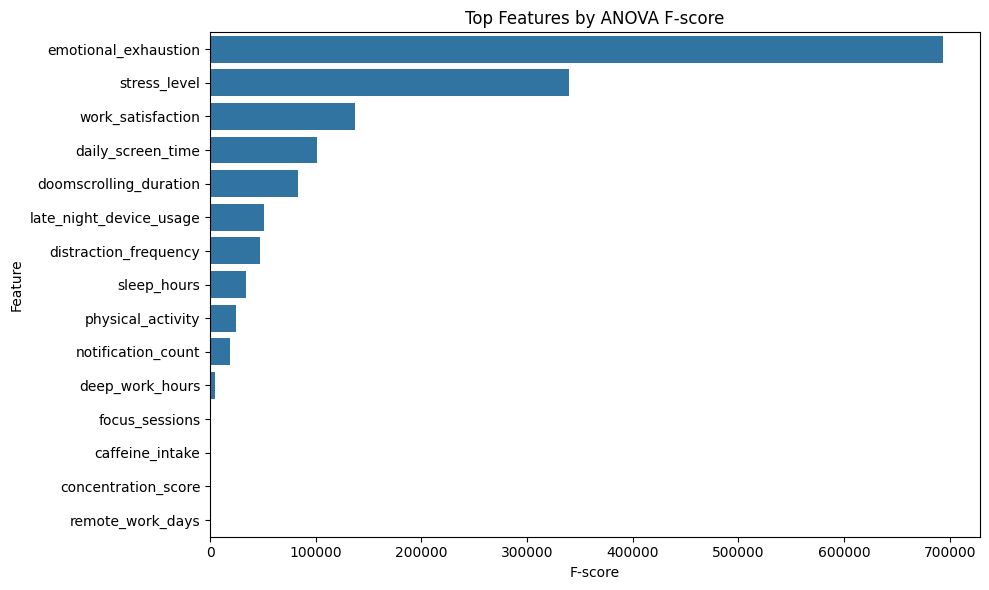

In [17]:
# Trực quan hóa 15 đặc trưng có F-score cao nhất

plt.figure(figsize=(10,6))

sns.barplot(

    data=anova_results.head(15),
    x="f_score",
    y="feature"

)

plt.title("Top Features by ANOVA F-score")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

Kết quả ANOVA F-test cho thấy có **12 đặc trưng** có sự khác biệt có ý nghĩa thống kê giữa ba mức Digital Burnout (p-value < 0,05).

Trong đó, các đặc trưng như **emotional_exhaustion**, **stress_level**, **work_satisfaction**, **daily_screen_time** và **doomscrolling_duration** đạt giá trị F-score rất cao, cho thấy khả năng phân biệt rõ giữa các nhóm Digital Burnout.

Các đặc trưng chưa đạt mức ý nghĩa thống kê sẽ không bị loại bỏ ngay mà tiếp tục được đánh giá thông qua Mutual Information và Random Forest Feature Importance nhằm đảm bảo việc lựa chọn đặc trưng dựa trên nhiều tiêu chí khác nhau.

# 4. Machine Learning Feature Assessment

Đánh giá mức độ quan trọng của các đặc trưng bằng phương pháp Machine Learning.

Khác với ANOVA F-test chỉ đánh giá sự khác biệt về mặt thống kê, Random Forest Feature Importance phản ánh mức độ đóng góp của từng đặc trưng trong quá trình xây dựng mô hình phân loại.

Kết quả này sẽ được sử dụng để so sánh với kết quả ANOVA trước khi xác định tập đặc trưng cuối cùng.

- Random Forest Feature Importance
- So sánh với kết quả ANOVA
- Xác định các đặc trưng được lựa chọn


## 4.1 Random Forest Feature Importance

Đánh giá mức độ quan trọng của từng đặc trưng thông qua Random Forest Classifier.

Trong Random Forest, mức độ quan trọng của đặc trưng được xác định dựa trên mức giảm độ hỗn loạn (impurity reduction) mà đặc trưng đó tạo ra trong toàn bộ các cây quyết định.

Các đặc trưng có Feature Importance cao được xem là đóng góp nhiều hơn vào khả năng phân biệt các mức Digital Burnout.

In [18]:
from sklearn.ensemble import RandomForestClassifier

Đây không phải mô hình chính của nghiên cứu, chỉ là mô hình phục vụ đánh giá đặc trưng. Vì vậy không cần GridSearch, Cross Validation hay tối ưu siêu tham số.

In [19]:
# Lấy mẫu đại diện

sample_df = df.sample(
    n=200000,
    random_state=42
)

X = sample_df[numerical_features]
y = sample_df[primary_target]


# Random Forest phục vụ Feature Importance

rf = RandomForestClassifier(

    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1

)

rf.fit(X, y)

print("Đã huấn luyện Random Forest để đánh giá Feature Importance.")

Đã huấn luyện Random Forest để đánh giá Feature Importance.


In [20]:
# Trích xuất Feature Importance

rf_importance = pd.DataFrame({

    "feature": numerical_features,
    "importance": rf.feature_importances_

})

rf_importance = (

    rf_importance

    .sort_values(
        by="importance",
        ascending=False
    )

    .reset_index(drop=True)

)

rf_importance.head(10)

,feature,importance
0,emotional_exhaustion,0.227302
1,stress_level,0.135371
2,daily_screen_time,0.067815
3,work_satisfaction,0.065593
4,doomscrolling_duration,0.054545
5,distraction_frequency,0.045728
6,sleep_hours,0.037063
7,notification_count,0.035040
8,physical_activity,0.030053
9,deep_work_hours,0.025811


In [21]:
# Xếp hạng Feature Importance

rf_importance["rf_rank"] = (

    rf_importance["importance"]

    .rank(
        method="dense",
        ascending=False
    )

    .astype(int)

)

rf_importance.head(15)

,feature,importance,rf_rank
0,emotional_exhaustion,0.227302,1
1,stress_level,0.135371,2
2,daily_screen_time,0.067815,3
3,work_satisfaction,0.065593,4
4,doomscrolling_duration,0.054545,5
5,distraction_frequency,0.045728,6
6,sleep_hours,0.037063,7
7,notification_count,0.035040,8
8,physical_activity,0.030053,9
9,deep_work_hours,0.025811,10


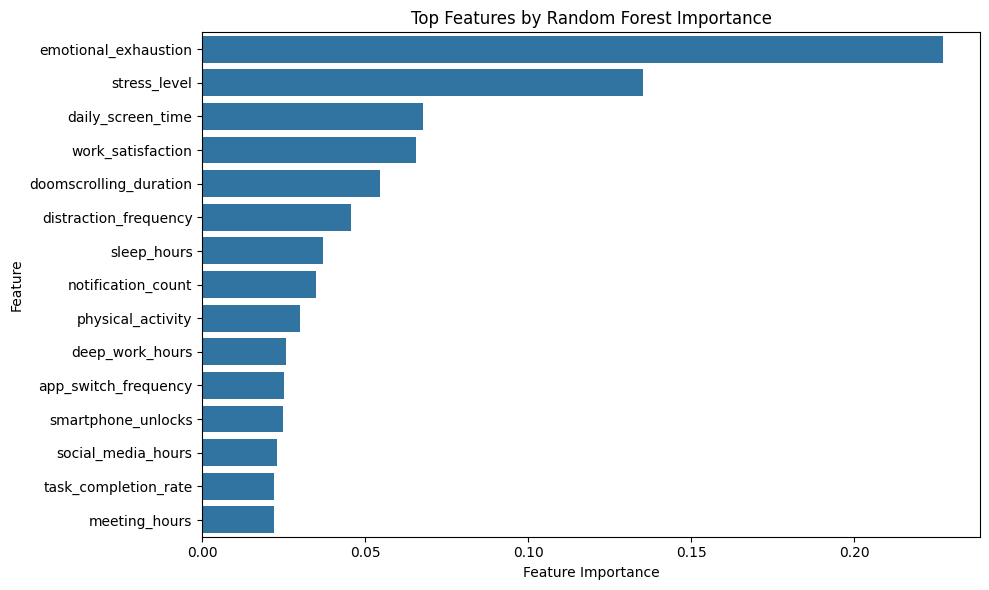

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=rf_importance.head(15),
    x="importance",
    y="feature"

)

plt.title("Top Features by Random Forest Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

## 4.2 Comparison with ANOVA Results

So sánh kết quả đánh giá đặc trưng giữa ANOVA F-test và Random Forest Feature Importance nhằm đánh giá mức độ nhất quán giữa phương pháp thống kê và phương pháp Machine Learning.

Mỗi đặc trưng sẽ được đối chiếu theo:

- Ý nghĩa thống kê (ANOVA)
- Mức độ quan trọng trong Random Forest
- Thứ hạng theo từng phương pháp

Kết quả là cơ sở để xác định tập đặc trưng cuối cùng ở phần tiếp theo.

In [23]:
comparison = (
    anova_results[
        [
            "feature",
            "f_score",
            "p_value",
            "significant"
        ]
    ]
    .merge(
        rf_importance[
            [
                "feature",
                "importance",
                "rf_rank"
            ]
        ],
        on="feature"
    )
)

comparison["anova_rank"] = (
    comparison["f_score"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

comparison["rank_difference"] = (
    comparison["anova_rank"]
    - comparison["rf_rank"]
).abs()

comparison = comparison.sort_values(
    by=["anova_rank", "rf_rank"]
).reset_index(drop=True)

display(comparison)

,feature,f_score,p_value,significant,importance,rf_rank,anova_rank,rank_difference
0,emotional_exhaustion,693837.690271,0.000000,True,0.227302,1,1,0
1,stress_level,339866.544911,0.000000,True,0.135371,2,2,0
2,work_satisfaction,137327.575101,0.000000,True,0.065593,4,3,1
3,daily_screen_time,101564.936783,0.000000,True,0.067815,3,4,1
4,doomscrolling_duration,83030.435719,0.000000,True,0.054545,5,5,0
5,late_night_device_usage,51096.709275,0.000000,True,0.020974,17,6,11
6,distraction_frequency,47473.588429,0.000000,True,0.045728,6,7,1
7,sleep_hours,33841.795330,0.000000,True,0.037063,7,8,1
8,physical_activity,24793.391802,0.000000,True,0.030053,9,9,0
9,notification_count,18957.139521,0.000000,True,0.035040,8,10,2


## 4.3 Final Validated Features

Xác định nhóm đặc trưng cuối cùng dựa trên kết quả đánh giá thống kê (ANOVA F-test) và đánh giá bằng Machine Learning (Random Forest Feature Importance).

Các đặc trưng được phân thành ba nhóm:

- **Core Feature**: Có ý nghĩa thống kê và đóng góp cao cho mô hình.
- **Validated Feature**: Có ý nghĩa thống kê nhưng mức đóng góp ở mức trung bình.
- **Supporting Feature**: Chưa đạt ý nghĩa thống kê nhưng vẫn được giữ lại để hỗ trợ quá trình xây dựng và giải thích mô hình ở các giai đoạn tiếp theo.

Việc phân nhóm này nhằm ưu tiên mức độ quan trọng của đặc trưng thay vì loại bỏ hoàn toàn ở giai đoạn Feature Validation.

In [24]:
# Tính giá trị trung bình của Feature Importance

importance_threshold = comparison["importance"].mean()

display(
    pd.DataFrame({
        "Chỉ số": ["Mean Feature Importance"],
        "Giá trị": [importance_threshold]
    })
)

,Chỉ số,Giá trị
0,Mean Feature Importance,0.038462


In [25]:
# Xây dựng quy tắc phân loại đặc trưng

def determine_feature_status(significant, importance):

    if significant and importance >= importance_threshold:
        return "Core Feature"
    elif significant:
        return "Validated Feature"
    else:
        return "Supporting Feature"

In [26]:
# Áp dụng quy tắc phân loại cho toàn bộ đặc trưng

validated_features = comparison.copy()

validated_features["feature_status"] = validated_features.apply(

    lambda row: determine_feature_status(

        row["significant"],
        row["importance"]

    ),

    axis=1

)

In [27]:
# Thiết lập thứ tự hiển thị cho các nhóm đặc trưng

status_order = {

    "Core Feature": 1,
    "Validated Feature": 2,
    "Supporting Feature": 3

}

validated_features["status_order"] = (

    validated_features["feature_status"]
    .map(status_order)

)

# Sắp xếp theo nhóm đặc trưng và thứ hạng Random Forest

validated_features = (

    validated_features

    .sort_values(

        by=[
            "status_order",
            "rf_rank"
        ],

        ascending=[True, True]

    )

    .drop(columns="status_order")
    .reset_index(drop=True)

)

In [28]:
# Thống kê số lượng đặc trưng theo từng nhóm

feature_summary = (

    validated_features["feature_status"]
    .value_counts()
    .rename_axis("Nhóm đặc trưng")
    .reset_index(name="Số lượng")

)

display(feature_summary)

,Nhóm đặc trưng,Số lượng
0,Supporting Feature,14
1,Core Feature,6
2,Validated Feature,6


In [29]:
# Hiển thị danh sách đặc trưng sau khi phân loại

display(validated_features)

,feature,f_score,p_value,significant,importance,rf_rank,anova_rank,rank_difference,feature_status
0,emotional_exhaustion,693837.690271,0.000000,True,0.227302,1,1,0,Core Feature
1,stress_level,339866.544911,0.000000,True,0.135371,2,2,0,Core Feature
2,daily_screen_time,101564.936783,0.000000,True,0.067815,3,4,1,Core Feature
3,work_satisfaction,137327.575101,0.000000,True,0.065593,4,3,1,Core Feature
4,doomscrolling_duration,83030.435719,0.000000,True,0.054545,5,5,0,Core Feature
5,distraction_frequency,47473.588429,0.000000,True,0.045728,6,7,1,Core Feature
6,sleep_hours,33841.795330,0.000000,True,0.037063,7,8,1,Validated Feature
7,notification_count,18957.139521,0.000000,True,0.035040,8,10,2,Validated Feature
8,physical_activity,24793.391802,0.000000,True,0.030053,9,9,0,Validated Feature
9,deep_work_hours,4322.093479,0.000000,True,0.025811,10,11,1,Validated Feature


Kết quả Feature Validation cho thấy 26 đặc trưng được phân thành ba nhóm dựa trên kết quả ANOVA F-test và Random Forest Feature Importance.

- **Core Feature (6 đặc trưng)** bao gồm: `emotional_exhaustion`, `stress_level`, `daily_screen_time`, `work_satisfaction`, `doomscrolling_duration` và `distraction_frequency`. Đây là nhóm đặc trưng vừa đạt ý nghĩa thống kê (p-value < 0.05) vừa có mức độ quan trọng cao hơn giá trị trung bình của Feature Importance, do đó được xem là các yếu tố cốt lõi trong việc dự đoán Digital Burnout.

- **Validated Feature (6 đặc trưng)** gồm: `sleep_hours`, `notification_count`, `physical_activity`, `deep_work_hours`, `late_night_device_usage` và `focus_sessions`. Các đặc trưng này đều có ý nghĩa thống kê nhưng mức độ đóng góp đối với mô hình thấp hơn nhóm Core Feature. Mặc dù vậy, đây vẫn là các biến quan trọng và sẽ được sử dụng trong quá trình xây dựng mô hình ở các notebook tiếp theo.

- **Supporting Feature (14 đặc trưng)** là những đặc trưng chưa đạt ý nghĩa thống kê trong kiểm định ANOVA. Tuy nhiên, các đặc trưng này vẫn được giữ lại nhằm hỗ trợ quá trình phân tích, so sánh và giải thích mô hình trong các giai đoạn tiếp theo thay vì bị loại bỏ ngay tại bước Feature Validation.

Nhìn chung, kết quả cho thấy các đặc trưng thuộc nhóm **Psychological Symptoms**, **Digital Exposure** và một phần **Lifestyle & Recovery** chiếm ưu thế trong nhóm Core và Validated Features. Điều này cho thấy các yếu tố liên quan đến trạng thái tâm lý, cường độ sử dụng thiết bị số và thói quen sinh hoạt có vai trò quan trọng trong việc phản ánh mức độ Digital Burnout, đồng thời tạo cơ sở cho việc xây dựng các mô hình dự đoán ở Notebook 05.

In [30]:
# Xuất kết quả Feature Validation

validated_features.to_csv(

    output_path,
    index=False

)

print(f"Đã lưu kết quả tại: {output_path}")

Đã lưu kết quả tại: ..\..\data\processed\international_dataset\validated_features.csv
